In [1]:
# Librerias necesarias
import os
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
from PIL import Image
#from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from datetime import datetime
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Conv2DTranspose, concatenate, Resizing, UpSampling2D
from tensorflow.keras.layers import  Flatten, Dense,BatchNormalization,MultiHeadAttention, LayerNormalization, Permute, Add,Reshape,GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.activations import gelu
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from skimage import exposure
from PIL import Image
import cv2
from scipy import ndimage
import matplotlib.pyplot as plt


# Cargar imágenes

In [ ]:

# Define las rutas a las carpetas
categorias = ['normal','benigno', 'maligno']

datos = []
etiquetas = []


In [ ]:
def read_imageResize_with_labels(dir='..\database\datasetV3'):
    """
    Lee imágenes de un directorio, las redimensiona a 224x224 píxeles y las etiqueta según 
    la subcarpeta en la que se encuentran. Las imágenes son procesadas en escala de grises.

    Parámetros:
    dir (str): La ruta del directorio principal que contiene las subcarpetas con las imágenes. 
               Las subcarpetas deben llamarse 'normal', 'benigno' y 'maligno' para que 
               las etiquetas se asignen correctamente. Las subcarpetas no definidas 
               recibirán una etiqueta de -1.

    Retorno:
    tuple: Una tupla que contiene dos elementos:
        - np.array: Un array de NumPy con las imágenes redimensionadas.
        - list: Una lista de etiquetas correspondientes a las imágenes.
    """
    labels = []
    imgs = []
    for subfolder in os.listdir(dir):
        
        subfolder_path = os.path.join(dir,subfolder)
        for name_image in os.listdir(subfolder_path):
            bandera = False    

            # Obtener la etiqueta desde el nombre de la subcarpeta
            if subfolder == 'normal':
                bandera = True
                labels.append(0)
            elif subfolder == 'benigno':
                bandera = True
                labels.append(1)
            elif subfolder == 'maligno':
                bandera = True
                labels.append(2)

            if bandera:    
           
                # Obtenemos la ruta de la imagen
                image_path = os.path.join(subfolder_path,name_image)
                
                # Read the image using TensorFlow for GPU acceleration
                image = cv2.imread(image_path,cv2.IMREAD_COLOR)
            
                imgs.append(image)
    
    return  np.array(imgs), labels

In [ ]:
# Leer las imagenes originales con sus etiquetas

imgs, labels = read_imageResize_with_labels(dir='../database/datasetV5')

In [10]:
# Comprobar la cantidad
print(imgs.shape)
print(len(labels))

(5984, 224, 224)
5984


In [11]:
# Verificar normalizacion
unicos = np.unique(imgs[0])
max(unicos)

255

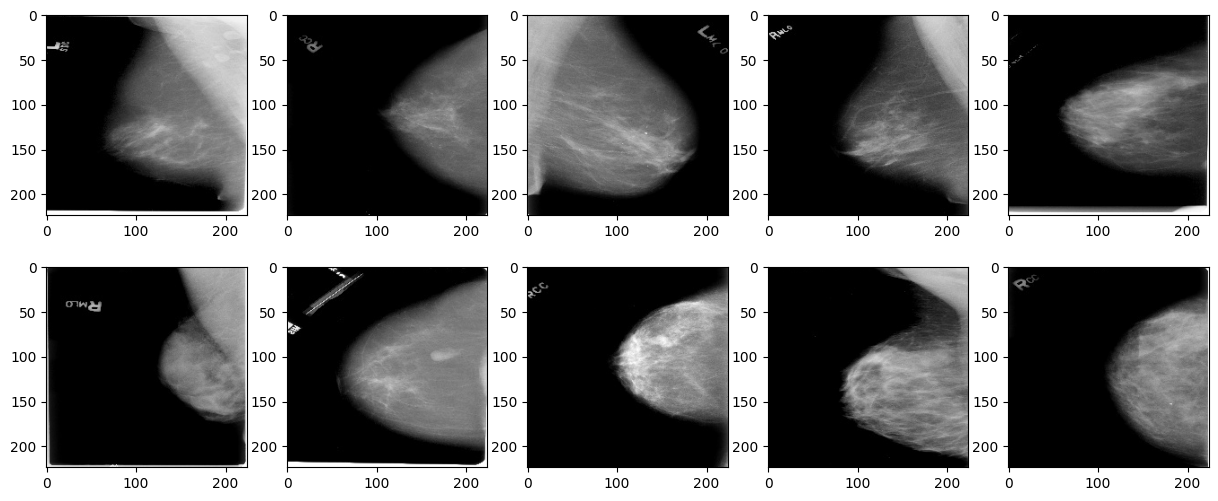

In [12]:
def show_imgs(imgs):
    '''
    Muestra una lista de imágenes en una matriz de 2 filas y 5 columnas utilizando Matplotlib.

    Parametros:
    - imgs: Una lista de matrices numpy representando las imágenes a mostrar.
    
    Esta función crea una figura con subtramas dispuestas en una matriz de 2x5.
    Recorre la lista de imágenes y las muestra en estas subtramas. Si hay menos de
    10 imágenes en la lista, los espacios restantes en la matriz quedan en blanco.
    '''
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))

    for i in range(2):
        for j in range(5):
            if i*5 + j < len(imgs):
                axes[i, j].imshow(imgs[i*5 + j],cmap = 'gray')
                #axes[i, j].axis('off')

    plt.show()
    
show_imgs(imgs)

In [13]:
unique_labels, unique_counts = np.unique(labels, return_counts=True)

# Crea un diccionario con las etiquetas y sus conteos
labels_histogram = dict(zip(unique_labels, unique_counts))

print(labels_histogram)

{0: 1994, 1: 1995, 2: 1995}


# Preparación conjuntos de train, test, val

In [ ]:
image_data = np.array(imgs)
labels = np.array(labels)



X_train=[]
X_test=[]
y_train=[]
y_test = []

In [15]:
del imgs

In [16]:

# Dividir en conjuntos de entrenamiento (70%) y temporal (30%), manteniendo el balance de etiquetas
X_train, X_temp, y_train, y_temp = train_test_split(image_data, labels, test_size=0.3, stratify=labels, random_state=42)

# Dividir el conjunto temporal en validación y prueba, manteniendo el balance de etiquetas
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

from collections import Counter 
# Verificar las proporciones en los conjuntos de entrenamiento, validación y prueba
print("Proporciones en el conjunto de entrenamiento:", Counter(y_train))
print("Proporciones en el conjunto de validación:", Counter(y_val))
print("Proporciones en el conjunto de prueba:", Counter(y_test))


Proporciones en el conjunto de entrenamiento: Counter({1: 1396, 0: 1396, 2: 1396})
Proporciones en el conjunto de validación: Counter({2: 300, 1: 299, 0: 299})
Proporciones en el conjunto de prueba: Counter({1: 300, 2: 299, 0: 299})


In [17]:
del image_data

In [18]:
print(type(X_train))

<class 'numpy.ndarray'>


In [19]:
print("Forma de X_train:", X_train.shape)
print("Forma de X_val:", X_val.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de y_val:", y_val.shape)
print("Forma de y_test:", y_test.shape)

Forma de X_train: (4188, 224, 224)
Forma de X_val: (898, 224, 224)
Forma de X_test: (898, 224, 224)
Forma de y_train: (4188,)
Forma de y_val: (898,)
Forma de y_test: (898,)


In [20]:
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)
X_val = np.expand_dims(X_val,axis=-1)


# Verifica las nuevas formas
print(f"Nueva forma de datos de entrenamiento: {X_train.shape}")
print(f"Nueva forma de datos de prueba: {X_test.shape}")
print(f"Nueva forma de datos de validacion: {X_test.shape}")

Nueva forma de datos de entrenamiento: (4188, 224, 224, 1)
Nueva forma de datos de prueba: (898, 224, 224, 1)
Nueva forma de datos de validacion: (898, 224, 224, 1)


In [ ]:
from keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical

# Convertir las etiquetas a codificación one-hot
y_train_one_hot = to_categorical(y_train, num_classes=3)
y_test_one_hot = to_categorical(y_test, num_classes=3)
y_val_one_hot = to_categorical(y_val, num_classes=3)

# Crea generadores de datos de imagen con aumento de datos
train_datagen = ImageDataGenerator(
    rescale=1./255  # Reescala las imágenes por el factor dado
)

test_datagen = ImageDataGenerator(rescale=1./255)

val_datagen = ImageDataGenerator(rescale=1./255)

# Crea generadores 
train_generator = train_datagen.flow(
    X_train,
    y_train_one_hot,
    batch_size=32
)

test_generator = test_datagen.flow(
    X_test,
    y_test_one_hot,
    batch_size=32
)

val_generator = val_datagen.flow(
    X_val,
    y_val_one_hot,
    batch_size=32
)


# Modelo

In [32]:
#Early stopping para que se detenga el entranamiento si a las 5 épocas no mejora el accuracy

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True
)


In [33]:

# callback para detener el entrenamiento si se alcanza el accuracy deseado
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('val_accuracy') > 0.84):
      print("Accuracy alcanzado")
      self.model.stop_training = True


In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import LeakyReLU,ELU
from tensorflow.keras import regularizers

model = Sequential()

# Primera capa convolucional
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1), padding='same'))
model.add(MaxPooling2D((2, 2)))

# Segunda capa convolucional
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))
# Aplanar para pasar a las capas densas
model.add(Flatten())

# Capa completamente conectada con 64 neuronas y regularización más ligera
model.add(Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.0001)))
model.add(Dropout(0.3))  # Dropout más ligero para mantener más información

# Capa de salida para 3 clases
model.add(Dense(3, activation='softmax'))

In [35]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 224, 224, 32)      320       
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 112, 112, 32)     0         
 2D)                                                             
                                                                 
 conv2d_6 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 56, 56, 64)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 56, 56, 128)       73856     
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 28, 28, 128)     

# Entrenamiento del modelo 

In [36]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [37]:
stop = myCallback()
with tf.device('/GPU:0'):
    history = model.fit(train_generator,
                        epochs=50,
                        validation_data=val_generator,
                        verbose=1,
                        callbacks=[early_stopping,stop])

Epoch 1/50
131/131 [==============================] - 12s 78ms/step - loss: 0.7163 - accuracy: 0.6671 - val_loss: 0.5259 - val_accuracy: 0.7628
Epoch 2/50
131/131 [==============================] - 10s 78ms/step - loss: 0.5066 - accuracy: 0.7512 - val_loss: 0.4549 - val_accuracy: 0.7951
Epoch 3/50
131/131 [==============================] - 10s 74ms/step - loss: 0.4677 - accuracy: 0.7779 - val_loss: 0.4410 - val_accuracy: 0.7840
Epoch 4/50
131/131 [==============================] - 10s 77ms/step - loss: 0.4373 - accuracy: 0.7980 - val_loss: 0.4291 - val_accuracy: 0.7951
Epoch 5/50
131/131 [==============================] - 10s 78ms/step - loss: 0.4228 - accuracy: 0.8104 - val_loss: 0.4155 - val_accuracy: 0.8118
Epoch 6/50
131/131 [==============================] - 10s 76ms/step - loss: 0.4031 - accuracy: 0.8257 - val_loss: 0.4220 - val_accuracy: 0.8185
Epoch 7/50
131/131 [==============================] - 10s 73ms/step - loss: 0.3846 - accuracy: 0.8398 - val_loss: 0.4209 - val_accuracy:

In [38]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy}")

29/29 [==============================] - 1s 30ms/step - loss: 0.4306 - accuracy: 0.8163
Test Accuracy: 0.8162583708763123


In [ ]:
#model.save('../models/modelo9_Mejor.h5')

In [39]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [40]:
# Visualización de curvas de pérdida y precisión
def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Curves')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.legend()
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curves')
    
    plt.show()

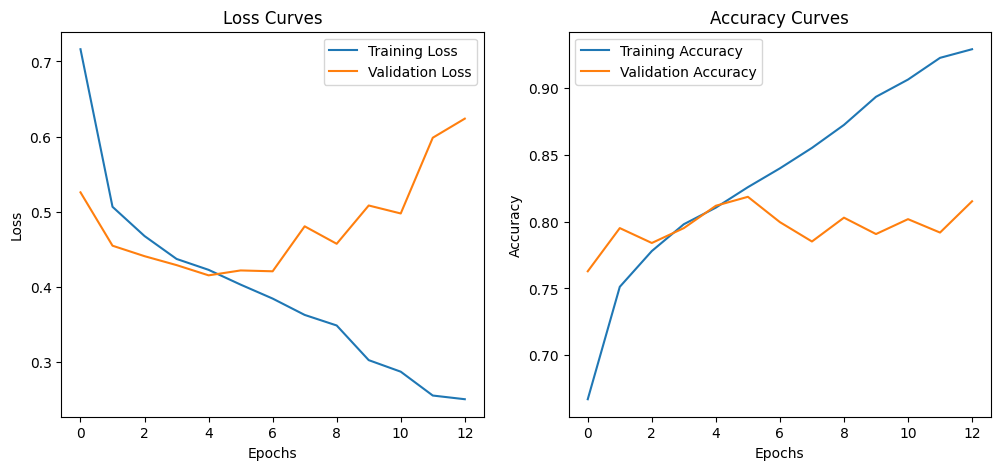

In [41]:
plot_training_history(history)

# Métricas de desempeño

29/29 [==============================] - 1s 28ms/step


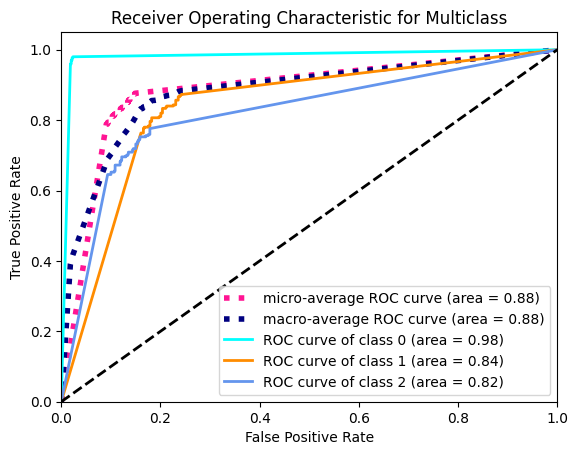

AUC for each class:
Class 0: 0.98
Class 1: 0.84
Class 2: 0.82
Micro-average AUC: 0.88
Macro-average AUC: 0.88


In [42]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np


y_pred_prob = model.predict(X_test)

n_classes = 3
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])

# Calcula ROC curve y ROC area para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcula la media micro y macro para ROC curve y ROC area
# Micro
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), y_pred_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot de las curvas ROC para cada clase y la media
plt.figure()
plt.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle=':', linewidth=4,
         label=f'micro-average ROC curve (area = {roc_auc["micro"]:.2f})')
plt.plot(fpr["macro"], tpr["macro"], color='navy', linestyle=':', linewidth=4,
         label=f'macro-average ROC curve (area = {roc_auc["macro"]:.2f})')

colors = ['aqua', 'darkorange', 'cornflowerblue']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {i} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multiclass')
plt.legend(loc='lower right')
plt.show()

# Imprimir los valores de AUC
print(f'AUC for each class:')
for i in range(n_classes):
    print(f'Class {i}: {roc_auc[i]:.2f}')
print(f'Micro-average AUC: {roc_auc["micro"]:.2f}')
print(f'Macro-average AUC: {roc_auc["macro"]:.2f}')


In [43]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Genera las predicciones del modelo
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convierte las predicciones en clases
y_true = []
for i in range(len(test_generator)):
    _, labels = test_generator[i]
    y_true.extend(labels.argmax(axis=1))  # Convierte a clases si es necesario

y_true = np.array(y_true)

# Obtén el reporte de clasificación
print("Classification Report:\n", classification_report(y_true, y_pred_classes))

29/29 [==============================] - 1s 30ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.31      0.32      0.31       299
           1       0.34      0.44      0.38       300
           2       0.32      0.22      0.26       299

    accuracy                           0.33       898
   macro avg       0.32      0.33      0.32       898
weighted avg       0.32      0.33      0.32       898



Matriz de Confusión:
[[286  11   2]
 [  3 235  62]
 [  8  96 195]]


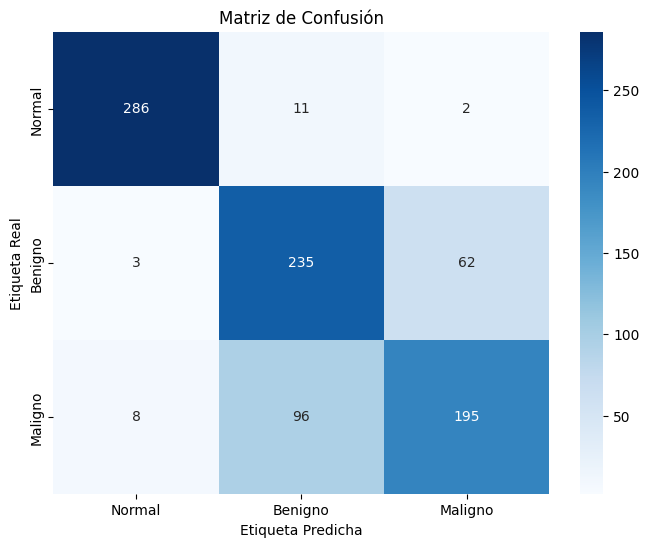

In [44]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Convierte las probabilidades en etiquetas de clase usando argmax
y_pred_class = np.argmax(y_pred_prob, axis=1)

# Paso 5: Calcula la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred_class)

# Paso 6: Muestra la matriz de confusión
print("Matriz de Confusión:")
print(conf_matrix)

# Paso 7: Visualiza la matriz de confusión usando una gráfica de calor (heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Benigno', 'Maligno'], yticklabels=['Normal', 'Benigno', 'Maligno'])
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión')
plt.show()

# Validación de varios runs (20)

In [ ]:
validation_accuracies = []

for run in range(20):
    # Crear un nuevo modelo para cada ejecución
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1), padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.0001)))
    model.add(Dropout(0.3))
    model.add(Dense(3, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    early_stopping = EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True
    )
    stop = myCallback()

    with tf.device('/GPU:0'):
        history = model.fit(
            train_generator,
            epochs=50,
            validation_data=val_generator,
            verbose=0,
            callbacks=[early_stopping, stop]
        )
    # Guardar la mejor precisión de validación alcanzada en esta ejecución
    val_acc = max(history.history['val_accuracy'])
    validation_accuracies.append(val_acc)
    print(f"Run {run+1}: Best validation accuracy = {val_acc:.4f}")

print("Validation accuracies over 20 runs:", validation_accuracies)
print(f"Mean validation accuracy: {np.mean(validation_accuracies):.4f}")
print(f"Std validation accuracy: {np.std(validation_accuracies):.4f}")

Run 1: Best validation accuracy = 0.8307
Run 2: Best validation accuracy = 0.8085
Run 3: Best validation accuracy = 0.8107
Run 4: Best validation accuracy = 0.8140
Run 5: Best validation accuracy = 0.8118
Run 6: Best validation accuracy = 0.8085
Run 7: Best validation accuracy = 0.8174
Run 8: Best validation accuracy = 0.8174
Run 9: Best validation accuracy = 0.8129
Run 10: Best validation accuracy = 0.8140
Run 11: Best validation accuracy = 0.8073
Run 12: Best validation accuracy = 0.8107
Run 13: Best validation accuracy = 0.8140
Run 14: Best validation accuracy = 0.8163
Run 15: Best validation accuracy = 0.8163
Run 16: Best validation accuracy = 0.8062
Run 17: Best validation accuracy = 0.8140
Run 18: Best validation accuracy = 0.8073
Run 19: Best validation accuracy = 0.8073
Run 20: Best validation accuracy = 0.8085
Validation accuracies over 20 runs: [0.8307349681854248, 0.8084632754325867, 0.8106904029846191, 0.814031183719635, 0.8118039965629578, 0.8084632754325867, 0.81737196445